# Data Fitting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dschick/udkm1Dsim/blob/develop/examples/05-xrays/05-data_fitting.ipynb)

Especially for light-scattering simulations, it is very common to also fit the simulations to some experimental data.

The **udkm1Dsim** toolbox is also able to do so using external fitting/minimizing packages such as [`scipy.optimize.minimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) or [`lmfit`](https://lmfit.github.io/lmfit-py).

In this example we first *generate* some experimental data by doing [resonant magnetic X-ray scattering](#example_resonant_magnetic_xray) simulations for a given `magnetization_map`, which we resue from the [M3TM model](#example_m3tm) example.
For the x-ray scattering, we will assume that the magnetic layer is made of **Fe** instead of **CoNi**.

In the fitting procedure, we will try to recover a simplified `magnetization_map` from the *experimental* data.

## Setup

Do all necessary imports and settings.

In [1]:
try:
    import udkm1Dsim as ud
except ImportError:
    %pip install udkm1Dsim[parallel]
    import udkm1Dsim as ud

u = ud.u  # import the pint unit registry from udkm1Dsim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units
from tqdm.auto import trange

## Structure

Refer to the [structure example](#example_structure) for more details.

In [2]:
Fe = ud.Atom('Fe', mag_amplitude=1, mag_phi=90*u.deg, mag_gamma=90*u.deg,
             atomic_form_factor_path='./Fe.cf')
Si = ud.Atom('Si')

In [3]:
prop_Fe = {}

layer_Fe = ud.AmorphousLayer('Fe', 'Fe amorphous', thickness=1*u.nm,
                             density=7874*u.kg/u.m**3, atom=Fe, **prop_Fe)

prop_Si = {}

layer_Si = ud.AmorphousLayer('Si', "Si amorphous", thickness=1*u.nm, density=2336*u.kg/u.m**3,
                             atom=Si, **prop_Si)

In [4]:
S = ud.Structure('Fe on Si')

S.add_sub_structure(layer_Fe, 20)
S.add_sub_structure(layer_Si, 50)

## Generate *Experimental* Data

### Magnetization Map
First we load the `magnetization` from the [M3TM example](#example_m3tm) and convert it to a proper `magnetization_map` of `amplitude` and `phi` and `gamma` angles.
Here we only adjust the `amplitude` and keep the orientation of the magnetization fixed out-of-plane.

In [5]:
m3tm_temp_map = np.load('m3tm_temp_map.npy')
# temporal grid is reduced by a factor of 10 to speed things up
m3tm_temp_map = m3tm_temp_map[0:-1:20, :, :]

magnetization_map = np.zeros_like(m3tm_temp_map)

for i in range(magnetization_map.shape[0]):
    # amplitude
    magnetization_map[i, :, 0] = m3tm_temp_map[i, :, 2]
    # phi
    magnetization_map[i, :, 1] = 0
    # gamma
    magnetization_map[i, :, 2] = 0

# compared to the M3TM example
delays = np.linspace(-1, 5, magnetization_map.shape[0])*u.ps
# spatial grid
_, _, distances = S.get_distances_of_layers()

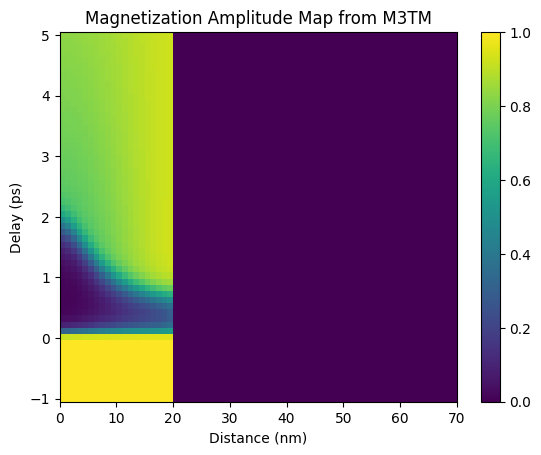

In [6]:
plt.figure()
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude,
               magnetization_map[:, :, 0], shading='auto')
plt.title('Magnetization Amplitude Map from M3TM')
plt.ylabel('Delay (ps)')
plt.xlabel('Distance (nm)')
plt.colorbar()
plt.show()

### Resonant Magnetic X-ray Scattering

See [resonant magnetic X-ray scattering example](#example_resonant_magnetic_xray) for details.

In [7]:
dyn_mag = ud.XrayDynMag(S, True)
dyn_mag.disp_messages = True
dyn_mag.save_data = False

exp_energy = 708*u.eV
exp_qz = np.r_[1:3.5:0.01]/u.nm

dyn_mag.energy = exp_energy  # set the energy range
dyn_mag.qz = exp_qz  # qz range
dyn_mag.set_polarization(2, 0)

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized
incoming polarizations set to: circ -
analyzer polarizations set to: unpolarized


In [8]:
R, R_phi, _, _ = dyn_mag.inhomogeneous_reflectivity(
    magnetization_map=magnetization_map
)


Calculating _inhomogeneous_reflectivity_ ...


Progress:   0%|          | 0/60 [00:00<?, ?it/s]

Elapsed time for _inhomogeneous_reflectivity_: 3.797760 s


:::{attention}
Here some artificial noise is added to the data
:::

In [9]:
# add some noise
noise_factor = 0.003
R_noisy = R*(1 + (np.random.random(R.shape)-0.5)*noise_factor)
R_phi_noisy = R_phi*(1 + (np.random.random(R.shape)-0.5)*noise_factor)

# calculate asymmetry
exp_asym = ((R_noisy-R_phi_noisy)/(R_noisy+R_phi_noisy))


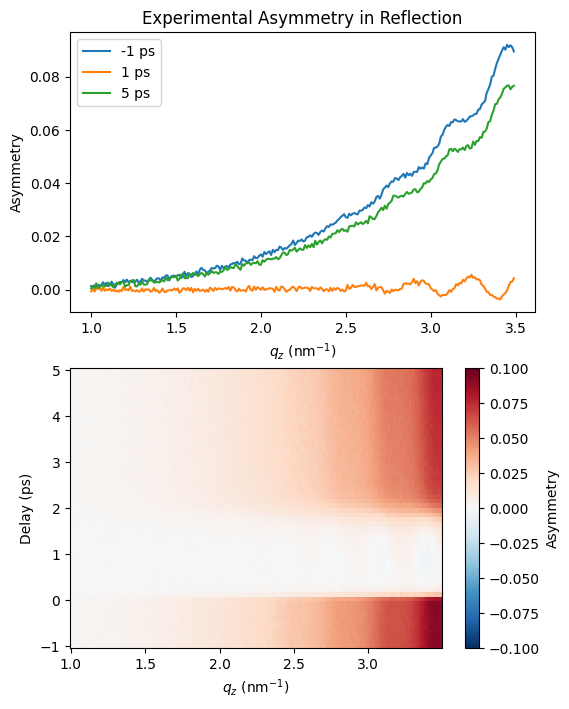

In [10]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.plot(dyn_mag.qz[0, :].to('1/nm'), exp_asym[0, 0, :], label='{:.2~g}'.format(delays[0]))
plt.plot(dyn_mag.qz[0, :].to('1/nm'), exp_asym[20, 0, :], label='{:.2~g}'.format(delays[20]))
plt.plot(dyn_mag.qz[0, :].to('1/nm'), exp_asym[-1, 0, :], label='{:.2~g}'.format(delays[-1]))

plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.ylabel('Asymmetry')
plt.legend()
plt.title('Experimental Asymmetry in Reflection')

plt.subplot(2, 1, 2)
plt.pcolormesh(dyn_mag.qz[0, :].to('1/nm').magnitude, delays.to('ps').magnitude,
               exp_asym[:, 0, :], shading='auto', vmin=-0.1, vmax=0.1, cmap='RdBu_r')

plt.ylabel('Delay (ps)')
plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.colorbar(label='Asymmetry')
plt.show()

## Fitting

For the fitting we will use the [`lmfit`](https://lmfit.github.io/lmfit-py) python package.

:::{attention}
`lmfit` is not a dependency of the **udkm1Dsim** toolbox, so you need to install it yourself, e.g. by

    > pip install lmfit

or

    > conda install lmfit
:::

In [`lmfit`](https://lmfit.github.io/lmfit-py) we build a fit `Model` by creating a `function` that best describes our experimental data.
The function will depend on a set of parameters, which will eventually be optimized.

In our case, we will again calculate the x-ray asymmetry from a given sample structure.
For the sake of simplicity, we just reuse the sample structure `S` from the data generation, see above.
In reality, `Layer` parameters, such as `thickness`, `density`, or `rhougness` can be easily integrated in the fit procedure.
Here, we will focus only on extracting a `magnetization_map`.

Again for simplicity, we will restrict the `magnetization_map` to follow a polynomial function in space

$$   m(z) = a + b\,z + c\,z^2 $$

for every delay in time. This is of course only an *educated guess* and can be adjusted to your needs

### Defining the Fit Function

In [11]:
def magnetization_profile(z, a, b, c):
    # simple polynomial function
    m = a + b*z + c*z**2
    return m

def xray_fitting_function(dyn_mag, a, b, c):
    dyn_mag.progress_bar = False
    dyn_mag.disp_messages = False
    L = dyn_mag.S.get_number_of_layers()
    # create a magnetization_map for a single delay
    # based on a, b, c
    magnetization_map = np.zeros([1, L, 3])
    z = np.arange(0, L)
    magnetization_map[0, :, 0] = magnetization_profile(z, a, b, c)
    R, R_phi, _, _ = dyn_mag.inhomogeneous_reflectivity(
        magnetization_map=magnetization_map
    )
    return ((R[0, :, :]-R_phi[0, :, :])/(R[0, :, :]+R_phi[0, :, :])).flatten()

Let's check what the function does for $a=1$ which is a constant magnetization of 100%:

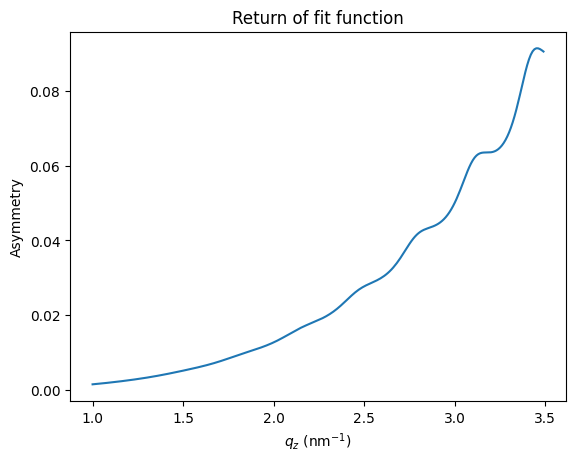

In [12]:
plt.figure()
plt.plot(exp_qz, xray_fitting_function(dyn_mag, 1, 0, 0))
plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.ylabel('Asymmetry')
plt.title('Return of fit function')
plt.show()

### Setup `lmfit`

In [13]:
import lmfit
# create a fitting model and tell lmfit which parameters are fixed/indepent
mod = lmfit.Model(xray_fitting_function, independent_vars=['dyn_mag'])

params = lmfit.Parameters()
params.add('a', value=1., vary=True)
params.add('b', value=0., vary=True)
params.add('c', value=0., vary=True)

Running the fit for a single delay of the *experimental* data is just:

In [14]:
data2fit = exp_asym[0, 0, :]
res = mod.fit(data2fit, params=params, dyn_mag=dyn_mag)

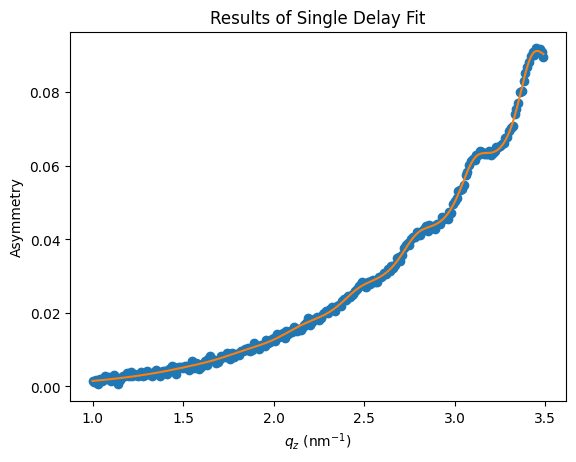

In [15]:
plt.figure()
plt.plot(exp_qz, data2fit, 'o')
plt.plot(exp_qz, res.best_fit, '-')
plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.ylabel('Asymmetry')
plt.title('Results of Single Delay Fit')
plt.show()

In [16]:
res.result

These were obviously good starting values. Now lets run the fitting routine for all delays:

### Fit Full Map

In [17]:
all_res = []
for i in trange(len(delays)):
    if i > 0:
        # use the results of the last fit
        # as starting values for the current one
        for key, par in params.items():
            params[key].value = all_res[i-1].best_values[key]

    data2fit = exp_asym[i, 0, :]
    all_res.append(mod.fit(data2fit, params=params, dyn_mag=dyn_mag))

  0%|          | 0/60 [00:00<?, ?it/s]

To be sure that the fitting worked out, we plot some of the *experimental* data together with the fit results for some selected delays:

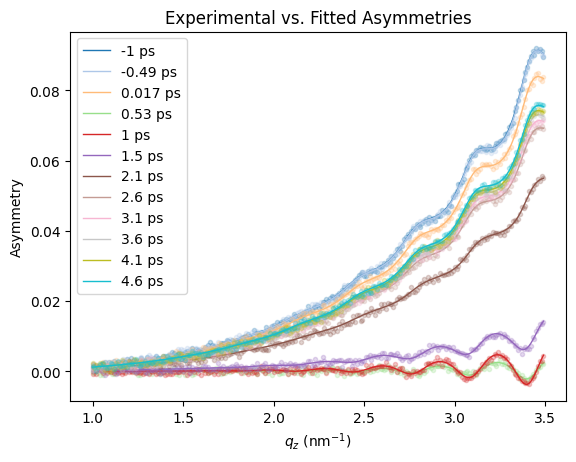

In [18]:
colors = plt.get_cmap("tab20", 60)
plt.figure()
for i, r in enumerate(all_res):
    if np.mod(i, 5) == 0:
        data2fit = exp_asym[i, 0, :]
        plt.plot(exp_qz, data2fit, '.', color=colors(i), alpha=0.25)
        plt.plot(exp_qz, r.best_fit, '-', label='{:.2~g}'.format(delays[i]),
                 color=colors(i), alpha=1, linewidth=1.)

plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.ylabel('Asymmetry')
plt.title('Experimental vs. Fitted Asymmetries')
plt.legend()
plt.show()

Plot the fitted `magnetization_map` in comparisson to the input map of the *experimental* data generation:

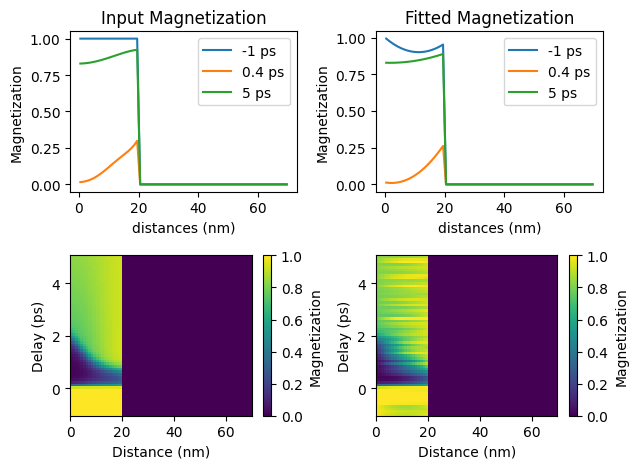

In [19]:
# assign fit results to magnetization_map
z = np.arange(0, len(distances))
fit_magnetization_map = np.zeros([len(delays), len(distances)])
for i, r in enumerate(all_res):
    # only assign first 20 elements for Fe layer
    fit_magnetization_map[i, 0:20] = magnetization_profile(
        z[0:20],
        r.best_values['a'],
        r.best_values['b'],
        r.best_values['c']
        )

plt.figure()
# input lineouts
plt.subplot(2, 2, 1)

plt.plot(distances.to('nm'), magnetization_map[0, :, 0], label='{:.1~g}'.format(delays[0]))
plt.plot(distances.to('nm'), magnetization_map[14, :, 0], label='{:.1~g}'.format(delays[14]))
plt.plot(distances.to('nm'), magnetization_map[-1, :, 0], label='{:.1~g}'.format(delays[-1]))
plt.xlabel('distances (nm)')
plt.ylabel('Magnetization')
plt.legend()
plt.title('Input Magnetization')

# fit results lineouts
plt.subplot(2, 2, 2)

plt.plot(distances.to('nm'), fit_magnetization_map[0, :], label='{:.1~g}'.format(delays[0]))
plt.plot(distances.to('nm'), fit_magnetization_map[14, :], label='{:.1~g}'.format(delays[14]))
plt.plot(distances.to('nm'), fit_magnetization_map[-1, :], label='{:.1~g}'.format(delays[-1]))
plt.xlabel('distances (nm)')
plt.ylabel('Magnetization')
plt.legend()
plt.title('Fitted Magnetization')

# input map
plt.subplot(2, 2, 3)

plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude,
               magnetization_map[:, :, 0], shading='auto', vmin=0, vmax=1)

plt.ylabel('Delay (ps)')
plt.xlabel('Distance (nm)')
plt.colorbar(label='Magnetization')

# fit results map
plt.subplot(2, 2, 4)

plt.pcolormesh(distances.to('nm'), delays.to('ps'),
               fit_magnetization_map[:, :], shading='auto', vmin=0, vmax=1)
plt.ylabel('Delay (ps)')
plt.xlabel('Distance (nm)')
plt.colorbar(label='Magnetization')

plt.tight_layout()
plt.show()

The fitting loop over different delays can be also easily parallelized, using e.g. [Dask](https://docs.dask.org/en/latest/).